In [1]:
# https://platform.olimpiada-ai.ro/ro/problems/200

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [2]:
data = pd.read_csv("/kaggle/input/datasets/abukanabek/sparks/dataset.csv")
data.shape

(31250, 4)

In [3]:
data.head()

,Name,Timestamp,X,Y
0,qdugzqd,"Jan 26, 2026, 12:00:03 AM",54.019410,69.212326
1,qdugzqd,"Jan 26, 2026, 12:00:03 AM",176.670391,66.628831
2,qdugzqd,"Jan 26, 2026, 12:00:03 AM",185.917840,105.632155
3,qdugzqd,"Jan 26, 2026, 12:00:03 AM",127.891247,52.613789
4,qdugzqd,"Jan 26, 2026, 12:00:03 AM",89.019781,36.288286


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31250 entries, 0 to 31249
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Name       31250 non-null  object 
 1   Timestamp  31250 non-null  object 
 2   X          31250 non-null  float64
 3   Y          31250 non-null  float64
dtypes: float64(2), object(2)
memory usage: 976.7+ KB


In [5]:
data['Timestamp_dt'] = pd.to_datetime(data['Timestamp'])
data = data.sort_values(['Timestamp_dt', 'X', 'Y']).reset_index(drop=True)
data.head()

/tmp/ipykernel_55/1683514245.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Timestamp_dt'] = pd.to_datetime(data['Timestamp'])


,Name,Timestamp,X,Y,Timestamp_dt
0,qdugzqd,"Jan 26, 2026, 12:00:03 AM",53.168377,68.049850,2026-01-26 00:00:03
1,qdugzqd,"Jan 26, 2026, 12:00:03 AM",53.188307,68.246373,2026-01-26 00:00:03
2,qdugzqd,"Jan 26, 2026, 12:00:03 AM",53.213316,68.314318,2026-01-26 00:00:03
3,qdugzqd,"Jan 26, 2026, 12:00:03 AM",53.213679,69.084287,2026-01-26 00:00:03
4,qdugzqd,"Jan 26, 2026, 12:00:03 AM",53.286708,68.524936,2026-01-26 00:00:03


In [6]:
data['Timestamp_dt'].unique()

<DatetimeArray>
['2026-01-26 00:00:03', '2026-01-26 00:00:11', '2026-01-26 00:00:17',
 '2026-01-26 00:00:23', '2026-01-26 00:00:30', '2026-01-26 00:00:37',
 '2026-01-26 00:00:46', '2026-01-26 00:00:53', '2026-01-26 00:00:59',
 '2026-01-26 00:01:07', '2026-01-26 00:01:14', '2026-01-26 00:01:19',
 '2026-01-26 00:01:27', '2026-01-26 00:01:34', '2026-01-26 00:01:42',
 '2026-01-26 00:01:47', '2026-01-26 00:01:54', '2026-01-26 00:02:02',
 '2026-01-26 00:02:08', '2026-01-26 00:02:17', '2026-01-26 00:02:23',
 '2026-01-26 00:02:30', '2026-01-26 00:02:38', '2026-01-26 00:02:45',
 '2026-01-26 00:02:52', '2026-01-26 00:02:58', '2026-01-26 00:03:05',
 '2026-01-26 00:03:12', '2026-01-26 00:03:20', '2026-01-26 00:03:27',
 '2026-01-26 00:03:33', '2026-01-26 00:03:41', '2026-01-26 00:03:47',
 '2026-01-26 00:03:53', '2026-01-26 00:04:01', '2026-01-26 00:04:09',
 '2026-01-26 00:04:16', '2026-01-26 00:04:23', '2026-01-26 00:04:29',
 '2026-01-26 00:04:36', '2026-01-26 00:04:44', '2026-01-26 00:04:49',
 '20

In [7]:
data['time_value'] = data['Timestamp_dt'].dt.minute * 60 + data['Timestamp_dt'].dt.second
data.head()

,Name,Timestamp,X,Y,Timestamp_dt,time_value
0,qdugzqd,"Jan 26, 2026, 12:00:03 AM",53.168377,68.049850,2026-01-26 00:00:03,3
1,qdugzqd,"Jan 26, 2026, 12:00:03 AM",53.188307,68.246373,2026-01-26 00:00:03,3
2,qdugzqd,"Jan 26, 2026, 12:00:03 AM",53.213316,68.314318,2026-01-26 00:00:03,3
3,qdugzqd,"Jan 26, 2026, 12:00:03 AM",53.213679,69.084287,2026-01-26 00:00:03,3
4,qdugzqd,"Jan 26, 2026, 12:00:03 AM",53.286708,68.524936,2026-01-26 00:00:03,3


In [8]:
def plot_multiple(n_rows=5, n_cols=5, offset=0, labels=None):
    n_rows, n_cols = 5, 5
    plt.figure(figsize=(12, 12))
    
    for i, tv in enumerate(data['time_value'].unique()):
        if i < offset:
            continue
        if i >= n_rows * n_cols + offset:
            break
        part = data[data['time_value']==tv][['X', 'Y']]
        plt.subplot(n_rows, n_cols, i-offset+1)
        plt.scatter(part.X, part.Y, c=labels[i] if labels is not None else None)
        plt.title(f'{tv} sec')
    
    plt.tight_layout()
    plt.show()

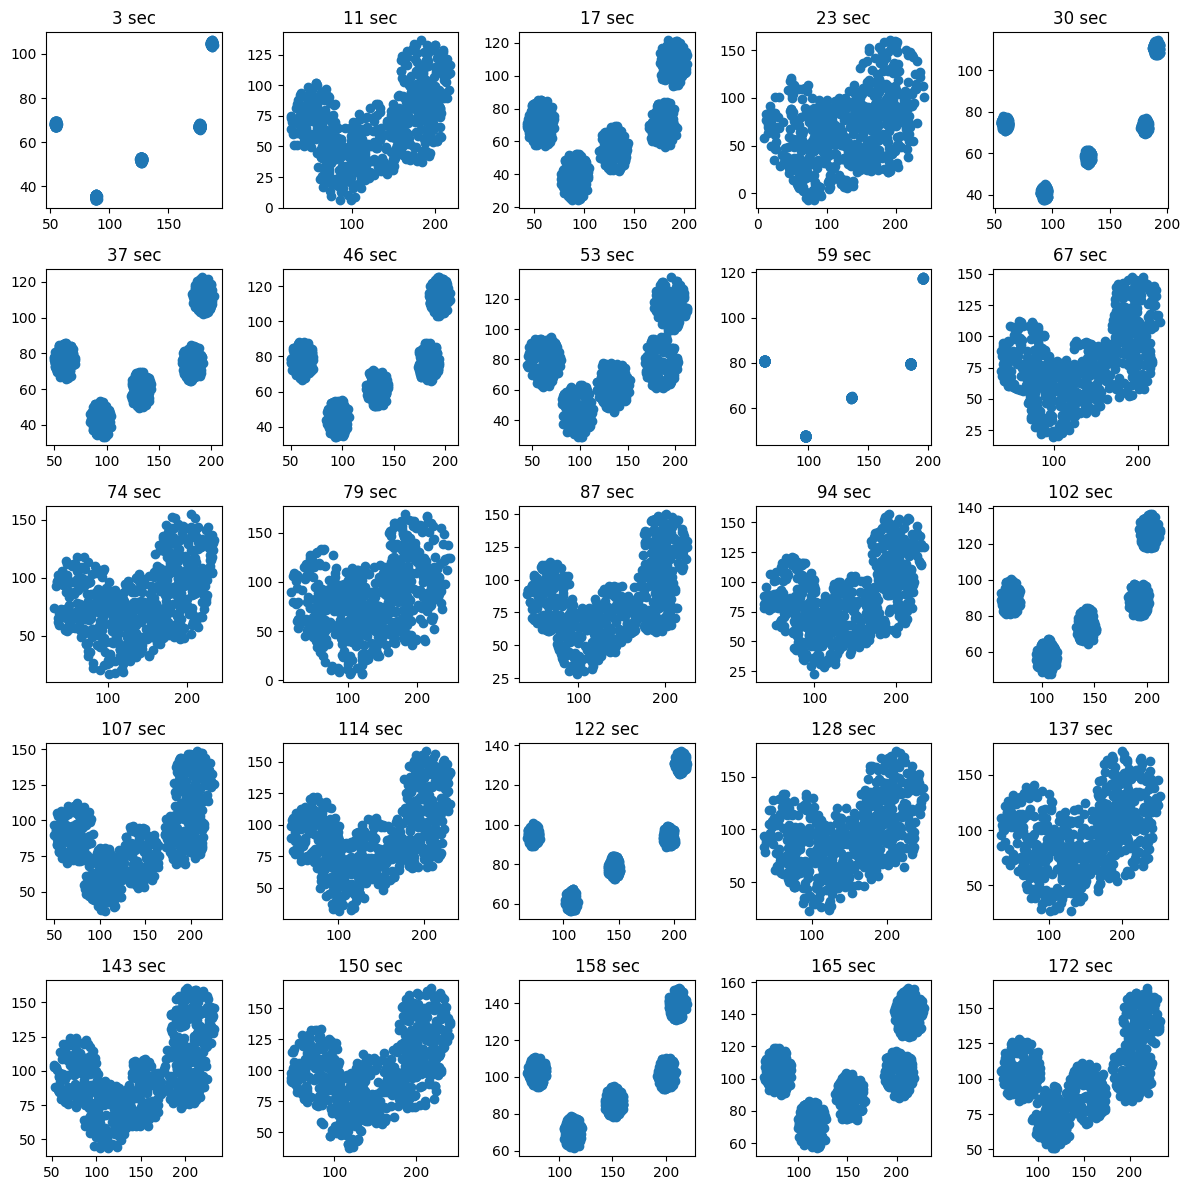

In [9]:
plot_multiple(offset=0)

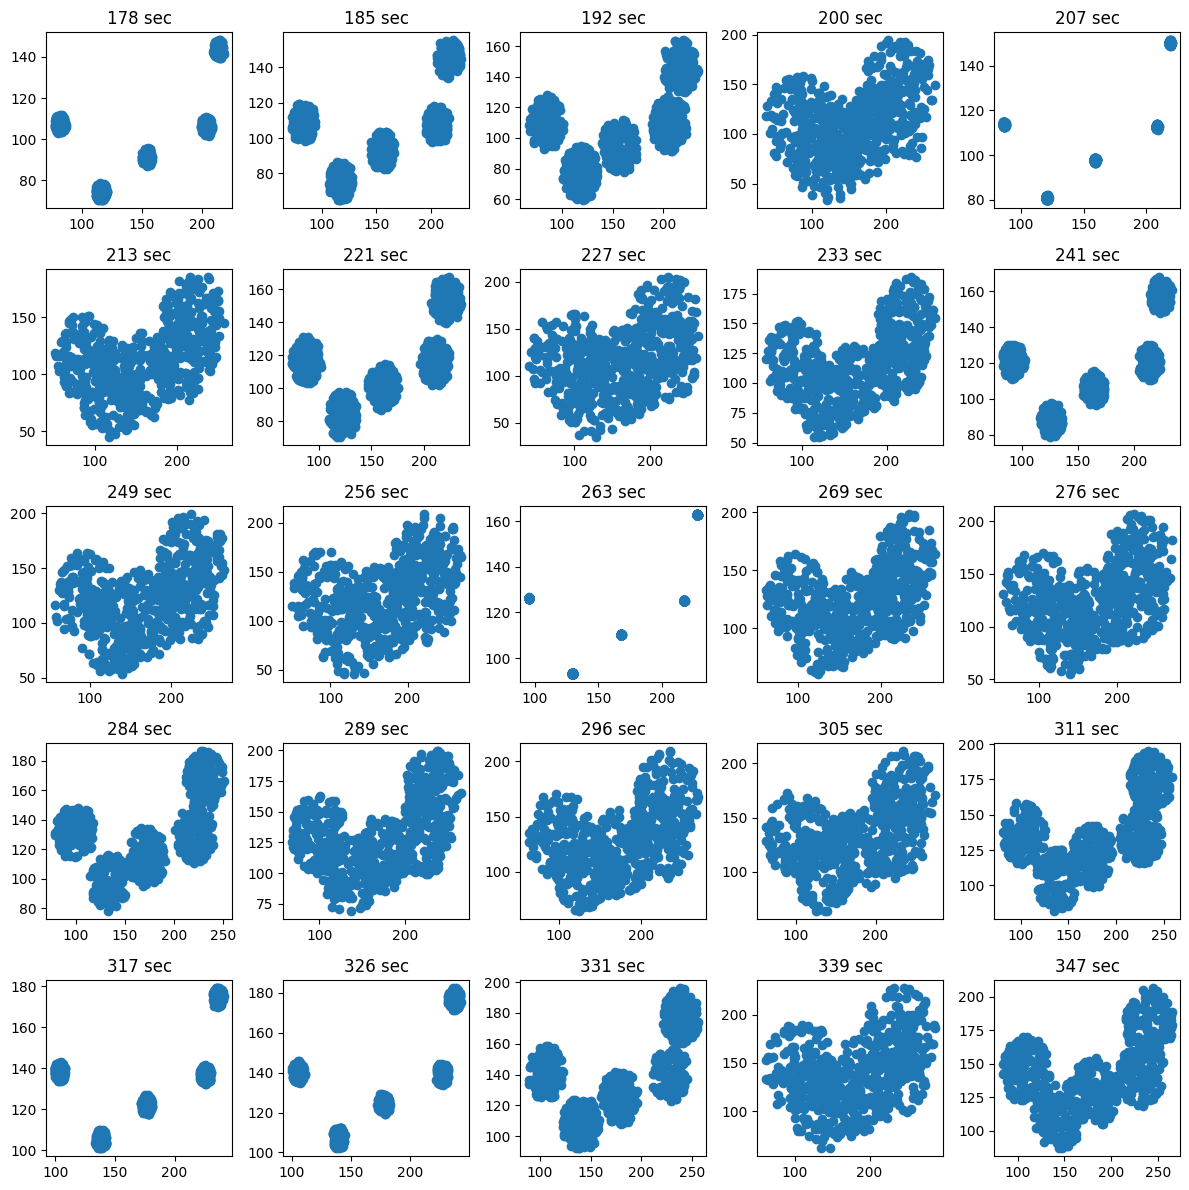

In [10]:
plot_multiple(offset=25)

In [11]:
from sklearn.cluster import KMeans

clusterer = KMeans(n_clusters=5)

part = data[data['time_value']==3][['X', 'Y']]

clusterer.fit(part)

centers = np.sort(clusterer.cluster_centers_, axis=0)
centers

array([[ 54.62844385,  35.30249776],
       [ 88.7628524 ,  52.15543685],
       [127.11129975,  67.23041177],
       [176.66201506,  68.35512374],
       [186.82262315, 104.63050812]])

In [12]:
labels = np.zeros((50, 625))
all_centers = np.zeros((50, 5, 2))

for i, tv in enumerate(data['time_value'].unique()):
    part = data[data['time_value']==tv][['X', 'Y']]
    clusterer = KMeans(n_clusters=5, init=centers + np.array(tv/7, tv/5))
    clusterer.fit(part)
    labels[i] = clusterer.labels_
    all_centers[i] = np.sort(clusterer.cluster_centers_, axis=0)

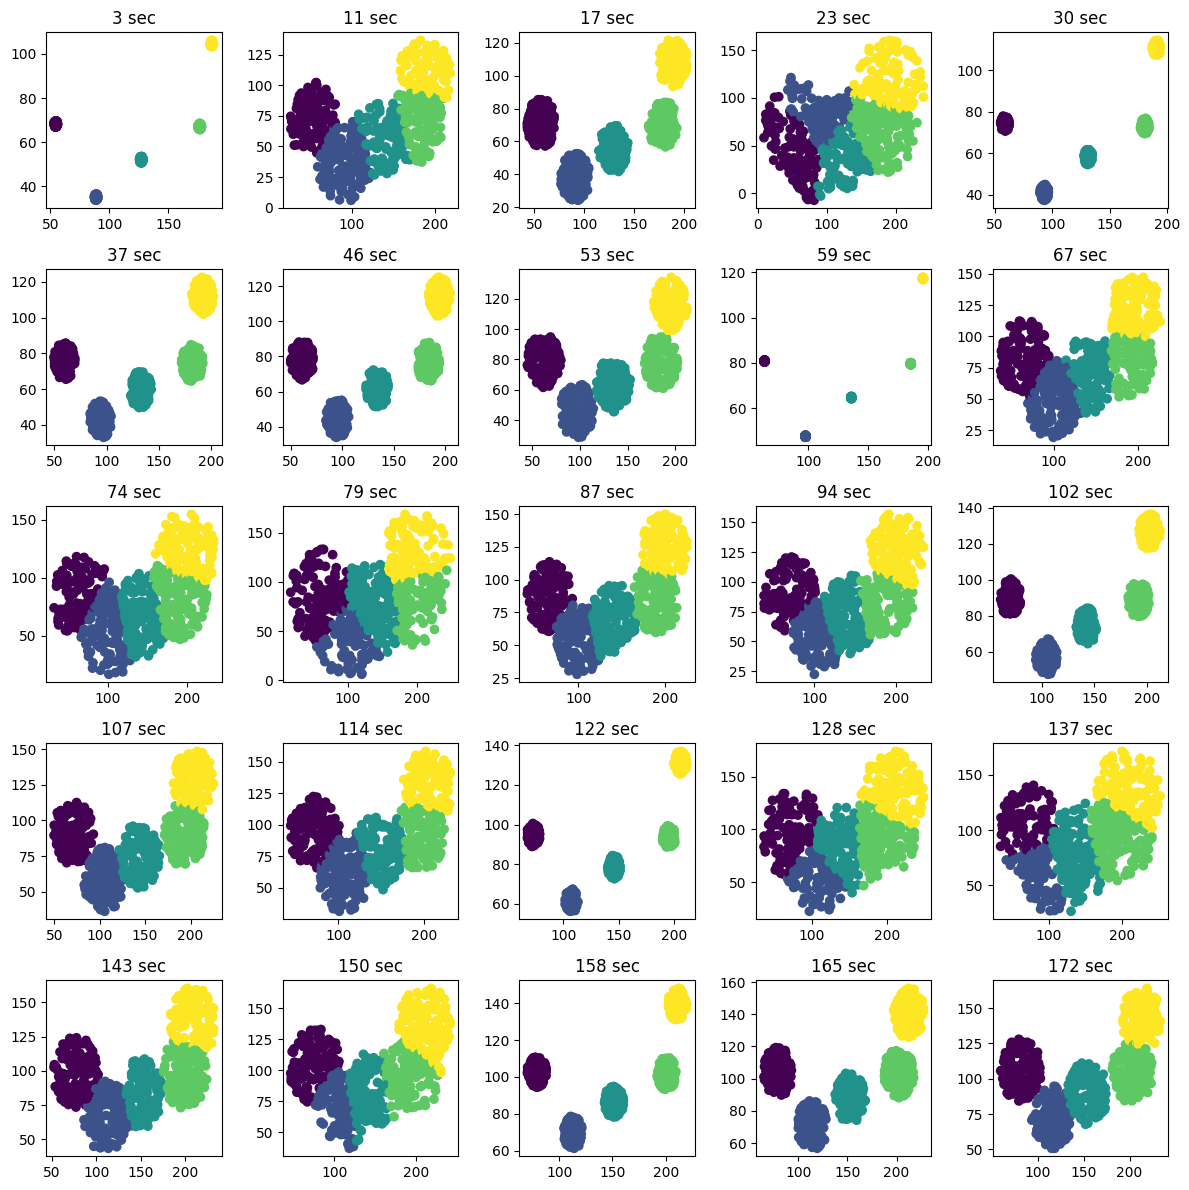

In [13]:
plot_multiple(offset=0, labels=labels)

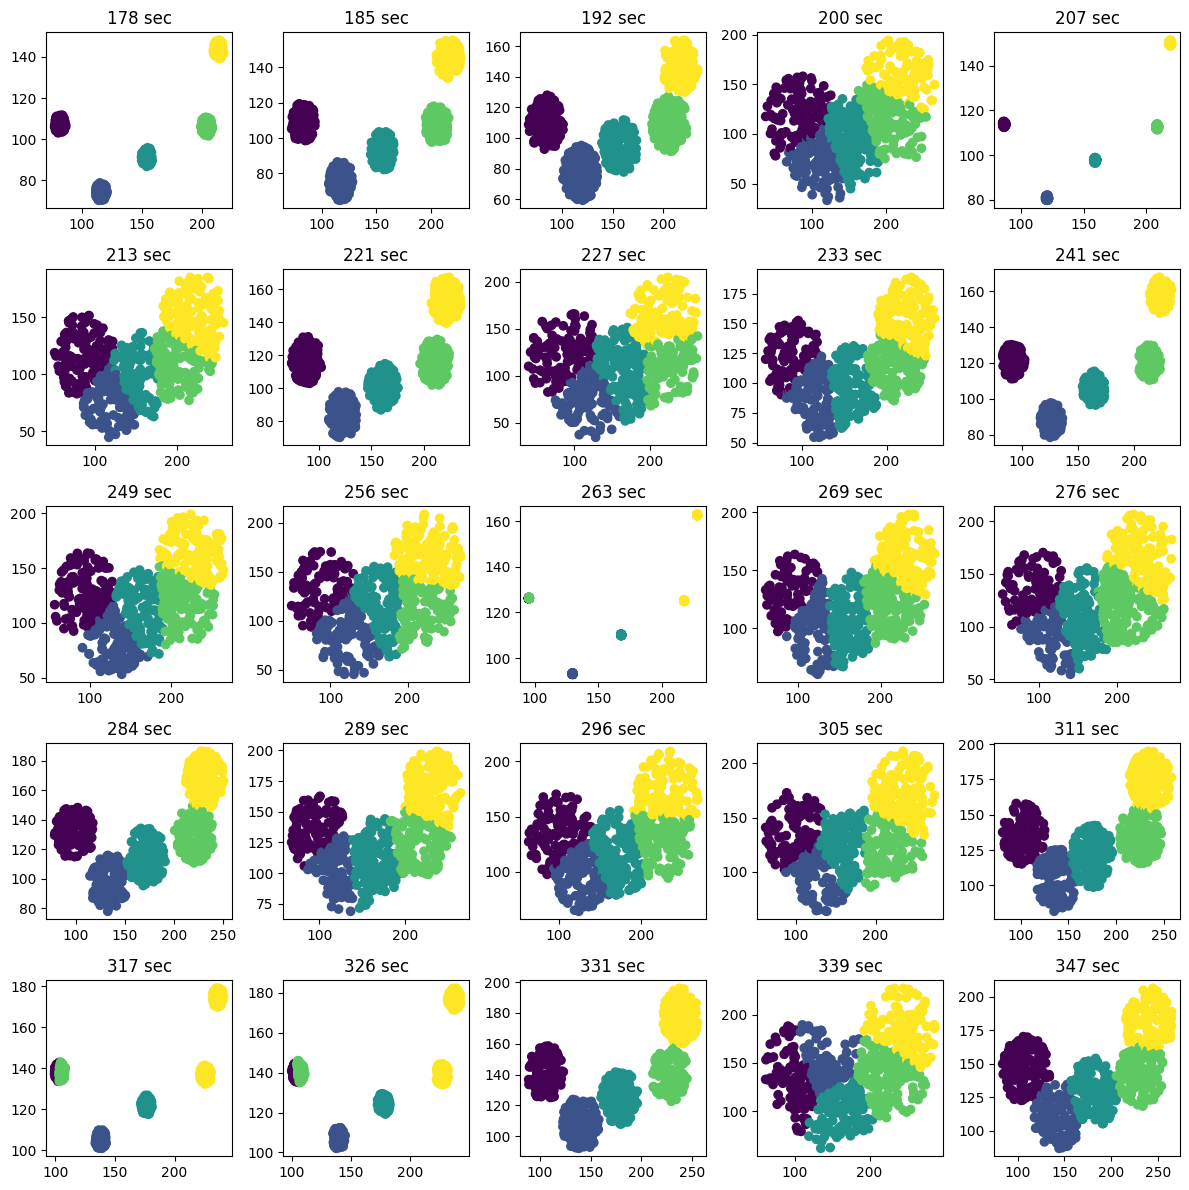

In [14]:
plot_multiple(offset=25, labels=labels)

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(data.time_value.unique().reshape((50, 1)), all_centers.reshape((50, 10)))

preds = model.predict([[500]]).reshape((5, 2))
preds

array([[129.16136046, 142.56281811],
       [149.46299357, 162.8351874 ],
       [184.12403608, 173.03307329],
       [234.4801464 , 182.42054524],
       [264.57609716, 209.06281694]])

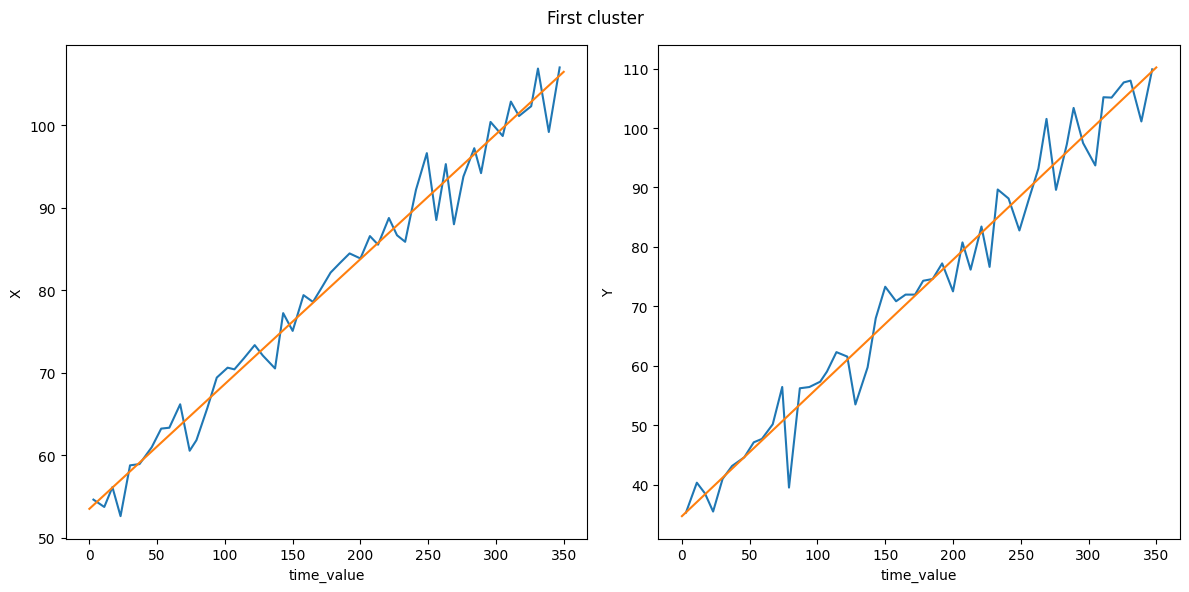

In [17]:
plt.figure(figsize=(12, 6))
plt.suptitle('First cluster')

plt.subplot(1, 2, 1)
plt.xlabel('time_value')
plt.ylabel('X')
plt.plot(data.time_value.unique(), all_centers[:, 0, 0])
lin = np.linspace(0, 350, 1000)
plt.plot(lin, lin*model.coef_[0]+model.intercept_[0])

plt.subplot(1, 2, 2)
plt.xlabel('time_value')
plt.ylabel('Y')
plt.plot(data.time_value.unique(), all_centers[:, 0, 1])
lin = np.linspace(0, 350, 1000)
plt.plot(lin, lin*model.coef_[1]+model.intercept_[1])

plt.tight_layout()
plt.show()

In [22]:
all_centers = model.predict(data['time_value'].unique().reshape(50, 1)).reshape(50, 5, 2)

In [23]:
subm = pd.DataFrame({
    'id': ['GLOBAL']*2 + (data['Timestamp'].unique().reshape(50, 1) + np.array([[f'|{i}' for i in range(5)]])).reshape(250).tolist() + (np.array(["Jan 26, 2026, 12:08:20 AM"]) + np.array([f'|{i}' for i in range(5)])).tolist(),
    'subtaskID': ['task1', 'task2'] + ['task3'] * 250 + ['task4'] * 5,
    'answer': [50, 5] + list(map(lambda x: f'{x[0]:.3f}|{x[1]:.3f}', all_centers.reshape(250, 2).tolist())) + list(map(lambda x: f'{x[0]:.3f}|{x[1]:.3f}', preds.tolist()))
})

subm.to_csv("submission.csv", index=False)

subm.head()

,id,subtaskID,answer
0,GLOBAL,task1,50
1,GLOBAL,task2,5
2,"Jan 26, 2026, 12:00:03 AM|0",task3,53.966|35.336
3,"Jan 26, 2026, 12:00:03 AM|1",task3,90.959|52.062
4,"Jan 26, 2026, 12:00:03 AM|2",task3,131.965|66.766
